# Univariate Approximation from Moments 

In [6]:
import torchorthopolys as top
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.stats
import matplotlib
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
# COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
# pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
DEFAULTFONTSIZE = 30
pyplot.rcParams['xtick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['axes.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams['figure.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams["axes.labelsize"] = DEFAULTFONTSIZE
pyplot.rcParams['legend.fontsize'] = DEFAULTFONTSIZE
pyplot.rcParams['font.size'] = DEFAULTFONTSIZE
pyplot.rcParams['lines.linewidth'] = 5
pyplot.rcParams['lines.markersize'] = 15
PW = 30 # inches

The distribution of $U_1+\dots+U_5$ with $U_1,\dots,U_5 \overset{\mathrm{IID}}{\sim} \mathcal{U}[0,1]$ is the 
[Irwin-Hall distribution](https://en.wikipedia.org/wiki/Irwin%E2%80%93Hall_distribution#Special_cases) on $[0,5]$ with density 
$$f(x) = \begin{cases} \frac{1}{24} x^4, & x \in [0,1] \\ \frac{1}{24} \left(-4 x^4 +20 x^3 - 30 x^2 + 20 x - 5\right), & x \in [1,2] \\ \frac{1}{24} \left(6 x^4 -60 x^3 +210 x^2 -300 x +155\right), & x \in [2,3] \\ \frac{1}{24} \left(-4 x^4 + 60 x^3 - 330 x^2 + 780 x - 655\right), & x \in [3,4] \\ \frac{1}{24} \left(x^4-20x^3+150x^2-500x+625\right), & x \in [4,5] \end{cases}.$$

In [7]:
def f(x):
    assert ((0<=x)*(x<=5)).all()
    y = torch.empty_like(x) 
    w0 = (0<=x)*(x<1)
    y[w0] = x[w0]**4
    w1 = (1<=x)*(x<2)
    y[w1] = -4*x[w1]**4+20*x[w1]**3-30*x[w1]**2+20*x[w1]-5
    w2 = (2<=x)*(x<3)
    y[w2] = 6*x[w2]**4-60*x[w2]**3+210*x[w2]**2-300*x[w2]+155
    w3 = (3<=x)*(x<4)
    y[w3] = -4*x[w3]**4+60*x[w3]**3-330*x[w3]**2+780*x[w3]-655
    w4 = (4<=x)*(x<=5)
    y[w4] = x[w4]**4-20*x[w4]**3+150*x[w4]**2-500*x[w4]+625
    return y/24
def F(x):
    assert ((0<=x)*(x<=5)).all()
    y = torch.empty_like(x)
    i0 = lambda x: (1/5*x**5)/24
    i1 = lambda x: (-4/5*x**5+20/4*x**4-30/3*x**3+20/2*x**2-5*x)/24
    i2 = lambda x: (6/5*x**5-60/4*x**4+210/3*x**3-300/2*x**2+155*x)/24
    i3 = lambda x: (-4/5*x**5+60/4*x**4-330/3*x**3+780/2*x**2-655*x)/24
    i4 = lambda x: (1/5*x**5-20/4*x**4+150/3*x**3-500/2*x**2+626*x)/24
    v0 = 0 
    w0 = (0<=x)*(x<1)
    y[w0] = v0+i0(x[w0])
    v1 = v0+i0(1)-i1(1)
    w1 = (1<=x)*(x<2)
    y[w1] = v1+i1(x[w1])
    v2 = v1+i1(2)-i2(2)
    w2 = (2<=x)*(x<3)
    y[w2] = v2+i2(x[w2])
    w3 = (3<=x)*(x<4)
    y[w3] = 1-(v1+i1(5-x[w3]))
    w4 = (4<=x)*(x<=5)
    y[w4] = 1-(v0+i0(5-x[w4]))
    return y
def mu_func(p):
    assert p>=0 and p%1==0
    k = torch.arange(p+1)
    i0 = lambda x: 1/(4+k+1)*x**(4+k+1)
    i1 = lambda x: -4/(4+k+1)*x**(4+k+1)+20/(3+k+1)*x**(3+k+1)-30/(2+k+1)*x**(2+k+1)+20/(1+k+1)*x**(1+k+1)-5/(k+1)*x**(k+1)
    i2 = lambda x: 6/(4+k+1)*x**(4+k+1)-60/(3+k+1)*x**(3+k+1)+210/(2+k+1)*x**(2+k+1)-300/(1+k+1)*x**(1+k+1)+155/(k+1)*x**(k+1)
    i3 = lambda x: -4/(4+k+1)*x**(4+k+1)+60/(3+k+1)*x**(3+k+1)-330/(2+k+1)*x**(2+k+1)+780/(1+k+1)*x**(1+k+1)-655/(k+1)*x**(k+1)
    i4 = lambda x: 1/(4+k+1)*x**(4+k+1)-20/(3+k+1)*x**(3+k+1)+150/(2+k+1)*x**(2+k+1)-500/(1+k+1)*x**(1+k+1)+625/(k+1)*x**(k+1)
    t = (i0(1)-i0(0))+(i1(2)-i1(1))+(i2(3)-i2(2))+(i3(4)-i3(3))+(i4(5)-i4(4))
    return t/24

In [8]:
def bisect_CDF(F, y, l, u, steps=10, rng=None):
    assert callable(F)
    assert isinstance(y,torch.Tensor)
    assert np.isfinite(l) and np.isscalar(l)
    assert np.isfinite(u) and np.isscalar(u) 
    assert l<u
    assert np.isfinite(steps) and np.isscalar(steps) and steps%1==0 and steps>=0
    if rng is None:
        rng = torch.Generator()
    elif isinstance(rng,int):
        rng = torch.Generator().manual_seed(rng)
    else:
        assert isinstance(rng,torch.Generator)
    yl_scalar = F(l*torch.ones(1))
    yu_scalar = F(u*torch.ones(1))
    if -1e-3<=yl_scalar<=0:
        yl_scalar = 0*yu_scalar
    if 1<=yu_scalar<=(1+1e-3):
        yu_scalar = 1+0*yu_scalar
    assert yl_scalar>=0, "F(l) = %s < 0, but F is supposed to be a CDF"%yl_scalar 
    assert yu_scalar<=1, "F(u) = %s > 1, but F is supposed to be a CDF"
    ymin = y.min()
    ymax = y.max()
    assert yl_scalar<=ymin, "F(l) = %s > %s = y.min(), try decreasing l or ensure y is in the correct range"%(yl_scalar,ymin)
    assert yu_scalar>=ymax, "F(u) = %s < %s = y.max(), try increasing u or ensure y is in the correct range"%(yu_scalar,ymax)
    yl = yl_scalar*torch.ones_like(y)
    yu = yu_scalar*torch.ones_like(y)
    xl = l*torch.ones_like(y) 
    xu = u*torch.ones_like(y)
    b = torch.ones_like(y,dtype=bool)
    ym = torch.empty_like(y)
    xm = torch.empty_like(y)
    bl = torch.zeros_like(y,dtype=bool)
    bu = torch.zeros_like(y,dtype=bool)
    for i in range(steps):
        xm[b] = (xl[b]+xu[b])/2
        ym[b] = F(xm[b])
        b2 = (yl[b]<ym[b])*(ym[b]<yu[b])
        b[b.clone()] = b2
        bl[:] = False 
        bu[:] = False
        bl[b] = y[b]>=ym[b]
        bu[b] = y[b]<=ym[b]
        xl[bl] = xm[bl]
        xu[bu] = xm[bu]
        if not b.any(): break
    assert (xl<=xu).all()
    return (xu-xl)*torch.rand(y.shape,generator=rng)+xl


xticks.shape = (1000,)
fticks.shape = (1000,)
mu.shape = (6,)
C.shape = (6, 6)
r.shape = (6,)
pticks.shape = (6, 1000)
wticks.shape = (1000,)
fhatticks.shape = (1000,)
muhat_trap.shape = (6,)
Fticks.shape = (1000,)
Fhatticks.shape = (1000,)
x.shape = (8192,)
xhat.shape = (8192,)


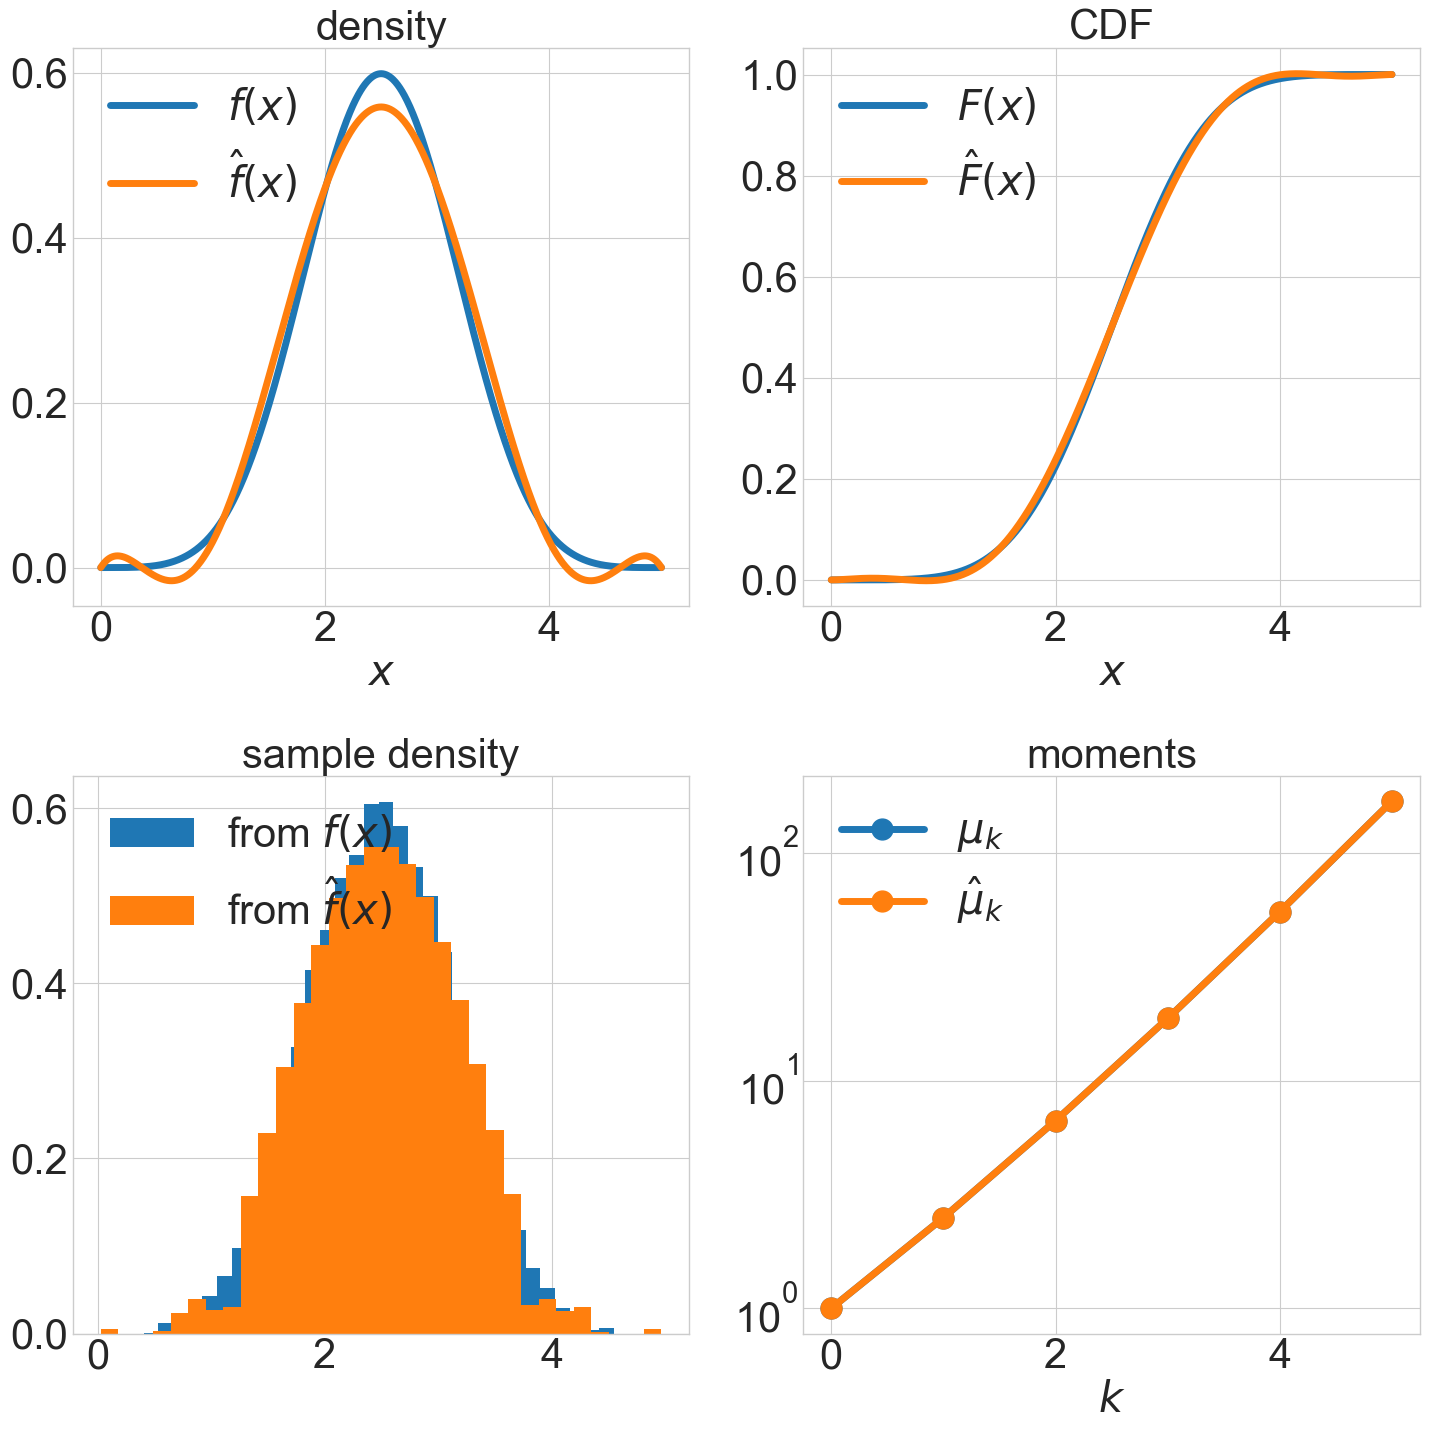

In [9]:
n = 5 # maximum moment
xticks = torch.linspace(0,5,1000)
print("xticks.shape = %s"%str(tuple(xticks.shape)))
fticks = f(xticks) 
print("fticks.shape = %s"%str(tuple(fticks.shape)))
mu = mu_func(n)
print("mu.shape = %s"%str(tuple(mu.shape)))
poly = top.Gegenbauer(alpha=1,loc=0,scale=5)
C = poly.coeffs(n)
print("C.shape = %s"%str(tuple(C.shape)))
r = torch.einsum("ij,j->i",C,mu)
print("r.shape = %s"%str(tuple(r.shape)))
pticks = poly(n,xticks)
print("pticks.shape = %s"%str(tuple(pticks.shape)))
wticks = poly.weight(xticks)
print("wticks.shape = %s"%str(tuple(wticks.shape)))
fhatticks = torch.einsum("i,i...->...",r,pticks)*wticks
print("fhatticks.shape = %s"%str(tuple(fhatticks.shape)))
muhat_trap = torch.trapezoid(xticks[None,:]**torch.arange(n+1)[:,None]*fhatticks,xticks,dim=-1)
print("muhat_trap.shape = %s"%str(tuple(muhat_trap.shape)))
Fticks = F(xticks) 
print("Fticks.shape = %s"%str(tuple(Fticks.shape)))
Fhatticks = torch.einsum("i,i...->...",r,poly.integral(n,xticks))
print("Fhatticks.shape = %s"%str(tuple(Fhatticks.shape)))
rng = torch.Generator().manual_seed(11)
N = 2**13 # number of random samples
x = torch.from_numpy(scipy.stats.qmc.Sobol(5,rng=11).random(N)).sum(-1)
print("x.shape = %s"%str(tuple(x.shape)))
xhat = bisect_CDF(
    F = lambda x: torch.einsum("i,i...->...",r,poly.integral(n,x)),
    y = torch.from_numpy(scipy.stats.qmc.Sobol(1,rng=11).random(N))[:,0],
    l = 0, 
    u = 5,
    steps = 100,
    rng = None,
    )
print("xhat.shape = %s"%str(tuple(xhat.shape)))
fig,ax = pyplot.subplots(nrows=2,ncols=2,figsize=(PW/2,PW/2))
ax[0,0].plot(xticks,fticks,label=r"$f(x)$")
ax[0,0].plot(xticks,fhatticks,label=r"$\hat{f}(x)$")
ax[0,0].set_title(r"density")
ax[0,0].set_xlabel(r"$x$")
ax[0,0].legend(frameon=False,loc="upper left")
ax[0,1].plot(xticks,Fticks,label=r"$F(x)$")
ax[0,1].plot(xticks,Fhatticks,label=r"$\hat{F}(x)$")
ax[0,1].set_title(r"CDF")
ax[0,1].set_xlabel(r"$x$")
ax[0,1].legend(frameon=False,loc="upper left")
ax[1,0].hist(x,bins=32,density=True,label=r"from $f(x)$")
ax[1,0].hist(xhat,bins=32,density=True,label=r"from $\hat{f}(x)$")
ax[1,0].legend(frameon=False,loc="upper left")
ax[1,0].set_title(r"sample density")
ax[1,1].plot(mu,'-o',label=r"$\mu_k$")
ax[1,1].plot(muhat_trap,'-o',label=r"$\hat{\mu}_k$")
ax[1,1].set_yscale("log",base=10)
ax[1,1].set_title(r"moments")
ax[1,1].set_xlabel(r"$k$")
ax[1,1].legend(frameon=False,loc="upper left")
fig.tight_layout()